In [ ]:
import pandas as pd
from datetime import datetime

def transform_inventory_pipeline(raw_data_path):
    # 1. Extract raw inventory logs
    df = pd.read_csv(raw_data_path)

    # 2. Transform: Clean missing values & calculate defect rate
    df['quantity_produced'] = df['quantity_produced'].fillna(0)
    df['is_defect'] = df['status'].apply(lambda x: 1 if x == 'DEFECT' else 0)

    # 3. Aggregate metrics per plant
    pipeline_summary = df.groupby('plant_id').agg(
        total_output=('quantity_produced', 'sum'),
        total_defects=('is_defect', 'sum')
    ).reset_index()

    pipeline_summary['defect_rate_pct'] = (
        pipeline_summary['total_defects'] / pipeline_summary['total_output']
    ) * 100

    return pipeline_summary

In [ ]:
import pandas as pd
import numpy as np

# 1. Simulate Raw Data Ingestion (Extract)
raw_data = {
    'transaction_id': [101, 102, 103, 104, 105],
    'plant_id': ['PL-BDG', 'PL-BDG', 'PL-JKT', 'PL-JKT', 'PL-BDG'],
    'quantity_produced': [5000, 450, 8000, 120, None], # Ada missing value
    'status': ['GOOD', 'DEFECT', 'GOOD', 'DEFECT', 'GOOD']
}
df_raw = pd.DataFrame(raw_data)

# 2. Transformation Pipeline (Transform)
df_clean = df_raw.copy()
df_clean['quantity_produced'] = df_clean['quantity_produced'].fillna(0)
df_clean['is_defect'] = df_clean['status'].apply(lambda x: 1 if x == 'DEFECT' else 0)

# 3. Aggregation & Metrics Calculation
df_etl_output = df_clean.groupby('plant_id').agg(
    total_output=('quantity_produced', 'sum'),
    total_defects=('is_defect', 'sum')
).reset_index()

df_etl_output['defect_rate_pct'] = (df_etl_output['total_defects'] / df_etl_output['total_output']) * 100

print("--- ETL PIPELINE RESULT ---")
display(df_etl_output)

--- ETL PIPELINE RESULT ---


,plant_id,total_output,total_defects,defect_rate_pct
0,PL-BDG,5450.0,1,0.018349
1,PL-JKT,8120.0,1,0.012315


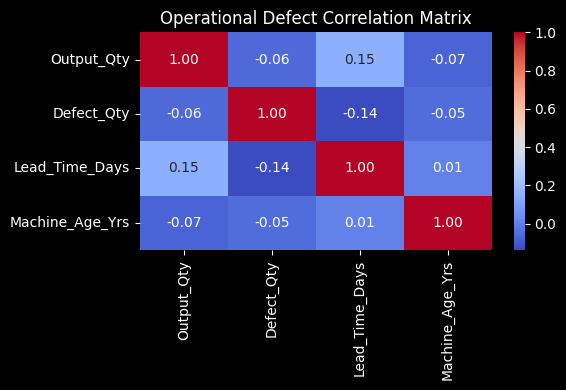

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sample Data Correlation Matrix
data = pd.DataFrame({
    'Output_Qty': np.random.randint(1000, 5000, 100),
    'Defect_Qty': np.random.randint(10, 200, 100),
    'Lead_Time_Days': np.random.randint(1, 10, 100),
    'Machine_Age_Yrs': np.random.randint(1, 8, 100)
})
plt.style.use('dark_background')
plt.figure(figsize=(6, 4))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Operational Defect Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Dummy Operational Dataset
np.random.seed(42)
X = pd.DataFrame({
    'output_qty': np.random.randint(1000, 5000, 200),
    'lead_time_days': np.random.randint(1, 10, 200),
    'machine_age_yrs': np.random.randint(1, 8, 200)
})
y = np.random.choice([0, 1], size=200, p=[0.8, 0.2]) # 0: Normal, 1: Defect Risk

# 2. Train-Test Split & Random Forest Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Model Evaluation
y_pred = rf_model.predict(X_test)
print("=== MODEL EVALUATION METRICS ===")
print(classification_report(y_test, y_pred))

=== MODEL EVALUATION METRICS ===
              precision    recall  f1-score   support

           0       0.78      0.86      0.82        29
           1       0.50      0.36      0.42        11

    accuracy                           0.72        40
   macro avg       0.64      0.61      0.62        40
weighted avg       0.70      0.72      0.71        40



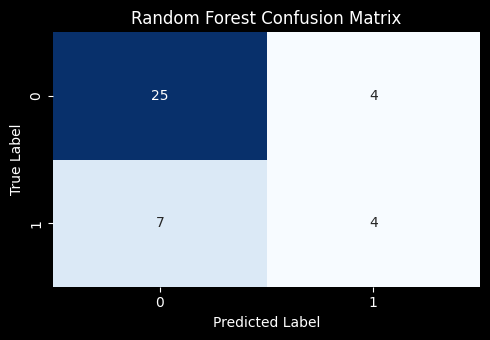

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
plt.figure(figsize=(5, 3.5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import sqlite3

# 1. Buat koneksi ke database SQLite di dalam memori (RAM)
conn = sqlite3.connect(":memory:")

# 2. Skrip DDL (Membuat Tabel) & DML (Mengisi Sample Data)
setup_script = """
CREATE TABLE dim_plants (
    plant_id INT PRIMARY KEY,
    plant_name VARCHAR(100)
);

CREATE TABLE fact_inventory_transactions (
    transaction_id INT PRIMARY KEY,
    plant_id INT REFERENCES dim_plants(plant_id),
    product_id INT,
    quantity_produced INT,
    status VARCHAR(20)
);

-- Contoh Data Sampel agar Query Mengeluarkan Hasil
INSERT INTO dim_plants VALUES
(1, 'Pabrik Jakarta'),
(2, 'Pabrik Surabaya'),
(3, 'Pabrik Bandung');

INSERT INTO fact_inventory_transactions VALUES
(101, 1, 10, 8000, 'OK'),
(102, 1, 10, 3000, 'DEFECT'),  -- Total output Pabrik JKT = 11.000 (> 10.000)
(103, 2, 20, 15000, 'OK'),
(104, 2, 20, 500, 'DEFECT'),   -- Total output Pabrik SBY = 15.500 (> 10.000)
(105, 3, 30, 5000, 'OK');       -- Total output Pabrik BDG = 5.000 (akan terfilter WHERE > 10000)
"""

# Jalankan skrip DDL & DML
conn.executescript(setup_script)

# 3. Query SQL Anda
sql_query = """
WITH MonthlyInventory AS (
    SELECT
        p.plant_id,
        p.plant_name,
        f.product_id,
        SUM(f.quantity_produced) AS total_output,
        -- Catatan: Di SQLite, cast total_defects ke REAL (FLOAT)
        -- agar pembagian desimal berjalan presisi
        SUM(CASE WHEN f.status = 'DEFECT' THEN CAST(f.quantity_produced AS REAL) ELSE 0 END) AS total_defects
    FROM fact_inventory_transactions f
    JOIN dim_plants p ON f.plant_id = p.plant_id
    GROUP BY p.plant_id, p.plant_name, f.product_id
)
SELECT
    plant_name,
    ROUND((total_defects / NULLIF(total_output, 0)) * 100, 2) AS defect_rate_pct
FROM MonthlyInventory
WHERE total_output > 10000
ORDER BY defect_rate_pct DESC;
"""

# 4. Jalankan query dan tampilkan hasilnya sebagai DataFrame pandas
df_result = pd.read_sql_query(sql_query, conn)
display(df_result)

,plant_name,defect_rate_pct
0,Pabrik Jakarta,27.27
1,Pabrik Surabaya,3.23
